In [1]:
# ============================================================
# 1. PROJECT SETUP AND IMPORTS
# ============================================================

# Discussion:
# This cell adds the project folder to Python's search path.
# This allows the notebook to import the Python modules created
# by the other group members.

import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

project_folder = r"C:\Users\kisha\Downloads\MV Assign\assignment_project_mv"

print("Project folder exists:", os.path.exists(project_folder))

if not os.path.exists(project_folder):
    raise FileNotFoundError(
        "Project folder was not found. Please check the folder path."
    )

if project_folder not in sys.path:
    sys.path.insert(0, project_folder)

print("Project folder successfully added to Python path.")

Project folder exists: True
Project folder successfully added to Python path.


In [2]:
# ============================================================
# 2. IMPORT MOSUJI AND PRAVEAN'S MODULES
# ============================================================

# Discussion:
# Mosuji's functions perform image preprocessing such as
# resizing, grayscale conversion, blurring, thresholding
# and morphology.
#
# Pravean's functions detect objects from the cleaned
# binary image and return their pixel dimensions.
#
# These detected object dimensions will then be passed
# to Kisha's calibration and measurement functions.

# ------------------------------------------------------------
# MOSUJI - IMAGE PROCESSING
# ------------------------------------------------------------

from image_processing import (
    resize_image,
    convert_to_grayscale,
    apply_gaussian_blur,
    apply_threshold,
    apply_morphology
)


# ------------------------------------------------------------
# PRAVEAN - CONTOUR OBJECT DETECTION
# ------------------------------------------------------------

from praveen_object_detection import (
    detect_objects,
    draw_bounding_boxes
)


# ------------------------------------------------------------
# PRAVEAN - REGIONPROPS OBJECT DETECTION
# ------------------------------------------------------------

from praveen_regionprops_detection import (
    detect_objects_regionprops,
    draw_regionprops_boxes
)


print("Mosuji and Pravean's modules imported successfully!")

ModuleNotFoundError: No module named 'cv'

In [3]:
# ============================================================
# 3. KISHA - CALIBRATION
# ============================================================

# Discussion:
# Calibration determines how many pixels represent one
# centimetre in the image.
#
# A reference object with a known real-world width is used.
# The detected pixel width is divided by the actual width
# to obtain the pixels-per-centimetre scale.

def calculate_pixels_per_cm(
    reference_width_pixels,
    reference_width_cm
):
    """
    Calculate pixels per centimetre.

    Formula:
        pixels_per_cm =
        reference_width_pixels / reference_width_cm
    """

    if reference_width_pixels <= 0:
        raise ValueError(
            "Reference width in pixels must be greater than 0."
        )

    if reference_width_cm <= 0:
        raise ValueError(
            "Reference width in cm must be greater than 0."
        )

    pixels_per_cm = (
        reference_width_pixels /
        reference_width_cm
    )

    return pixels_per_cm


def calibrate_from_object(
    reference_object,
    reference_width_cm
):
    """
    Calibrate using a detected reference object.
    """

    reference_width_pixels = (
        reference_object["width_pixels"]
    )

    return calculate_pixels_per_cm(
        reference_width_pixels,
        reference_width_cm
    )

In [4]:
# ============================================================
# 4 . KISHA - OBJECT MEASUREMENT
# ============================================================

# Discussion:
# After calibration, the detected object's dimensions are
# available in pixels. This code converts the width and
# height from pixels into centimetres using the calibration
# scale.

def measure_object(
    object_data,
    pixels_per_cm,
    object_id=1
):

    if pixels_per_cm <= 0:
        raise ValueError(
            "pixels_per_cm must be greater than 0."
        )

    width_pixels = object_data["width_pixels"]
    height_pixels = object_data["height_pixels"]

    width_cm = width_pixels / pixels_per_cm
    height_cm = height_pixels / pixels_per_cm

    return {
        "object_id": object_id,
        "width_pixels": width_pixels,
        "height_pixels": height_pixels,
        "width_cm": width_cm,
        "height_cm": height_cm,
        "area_pixels": object_data.get("area", 0)
    }


def measure_objects(
    objects,
    pixels_per_cm,
    skip_index=None
):

    measurements = []

    for index, obj in enumerate(objects):

        # Skip the reference object because it is
        # used only for calibration.
        if skip_index is not None and index == skip_index:
            continue

        measurement = measure_object(
            obj,
            pixels_per_cm,
            object_id=len(measurements) + 1
        )

        measurements.append(measurement)

    return measurements

In [5]:
# ============================================================
# 5. DISPLAY MEASUREMENTS
# ============================================================

def draw_measurements(
    image,
    objects,
    measurements,
    reference_index=None
):
    """
    Draw bounding boxes and width/height measurements on the image.

    The reference object can be highlighted separately by using
    reference_index (zero-based index in the objects list).
    """
    result = image.copy()
    measurement_number = 0

    for index, obj in enumerate(objects):

        x = obj["x"]
        y = obj["y"]
        width = obj["width_pixels"]
        height = obj["height_pixels"]

        # Do not label the reference object as a target object.
        if reference_index is not None and index == reference_index:
            cv2.rectangle(
                result,
                (x, y),
                (x + width, y + height),
                (255, 255, 0),
                2
            )

            cv2.putText(
                result,
                "Reference",
                (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 0),
                2
            )
            continue

        if measurement_number >= len(measurements):
            continue

        measurement = measurements[measurement_number]
        measurement_number += 1

        cv2.rectangle(
            result,
            (x, y),
            (x + width, y + height),
            (0, 255, 0),
            2
        )

        label_y = max(y - 10, 20)

        cv2.putText(
            result,
            f"Object {measurement['object_id']}",
            (x, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2
        )

        dimension_text = (
            f"W: {measurement['width_cm']:.2f} cm "
            f"H: {measurement['height_cm']:.2f} cm"
        )

        cv2.putText(
            result,
            dimension_text,
            (x, min(y + height + 20, result.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.50,
            (0, 255, 255),
            2
        )

    return result

In [6]:
# ============================================================
# 6. PRINT MEASUREMENT TABLE
# ============================================================

def print_measurement_table(measurements):
    """Print a simple table for checking results and report preparation."""
    print("\n" + "-" * 65)
    print("OBJECT MEASUREMENT RESULTS")
    print("-" * 65)
    print(
        f"{'Object':<10}"
        f"{'Width(px)':<12}"
        f"{'Height(px)':<13}"
        f"{'Width(cm)':<12}"
        f"{'Height(cm)':<12}"
    )
    print("-" * 65)

    for m in measurements:
        print(
            f"{m['object_id']:<10}"
            f"{m['width_pixels']:<12}"
            f"{m['height_pixels']:<13}"
            f"{m['width_cm']:<12.2f}"
            f"{m['height_cm']:<12.2f}"
        )

    print("-" * 65)


In [7]:
# ============================================================
# 7. FIND TEST IMAGES
# ============================================================

# Discussion:
# This cell searches the project folder for image files.
# The actual test image will be processed through the complete
# pipeline instead of using manually created object values.

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

image_files = []

for root, dirs, files in os.walk(project_folder):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_files.append(
                os.path.join(root, file)
            )


print("Images found:")
print("----------------")

for i, image_path in enumerate(image_files):

    print(
        f"{i}: {image_path}"
    )

Images found:
----------------


In [8]:
# ============================================================
# 8. SELECT TEST IMAGE
# ============================================================

# Choose the image number from the list above.

IMAGE_INDEX = 0

image_path = image_files[IMAGE_INDEX]

print("Selected image:")
print(image_path)

IndexError: list index out of range

In [9]:
# ============================================================
# 9. MOSUJI - IMAGE PREPROCESSING
# ============================================================

# Discussion:
# The original image is processed using Mosuji's functions.
# The image is resized, converted to grayscale, blurred,
# thresholded and cleaned using morphology.
#
# The final cleaned binary image will be passed to
# Pravean's object detection module.

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        "The selected image could not be loaded."
    )

print("Original image loaded.")
print("Image shape:", image.shape)


# Mosuji's preprocessing pipeline

resized = resize_image(image)

gray = convert_to_grayscale(resized)

blurred = apply_gaussian_blur(gray)

binary = apply_threshold(blurred)

cleaned = apply_morphology(binary)


print("Mosuji preprocessing completed!")

NameError: name 'image_path' is not defined

NameError: name 'resized' is not defined

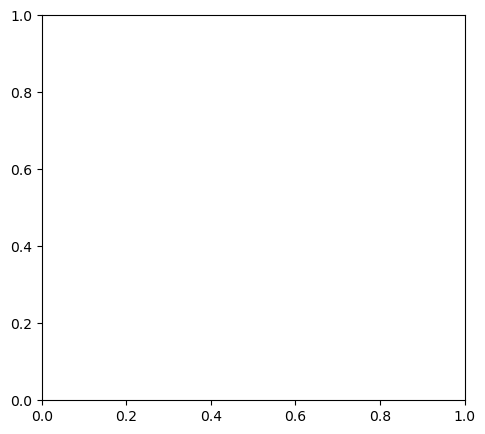

In [10]:
# ============================================================
# 10. DISPLAY PREPROCESSING RESULTS
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
)
plt.title("Original / Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cleaned, cmap="gray")
plt.title("Cleaned Binary Image")
plt.axis("off")

plt.show()

In [11]:
# ============================================================
# 11. PRAVEAN - OBJECT DETECTION
# ============================================================

# Discussion:
# Pravean's contour detection function receives the cleaned
# binary image produced by Mosuji.
#
# It detects individual objects and returns their bounding
# box coordinates, width, height and area in pixels.

objects = detect_objects(
    cleaned,
    min_area=1000
)

print("Number of detected objects:", len(objects))

for i, obj in enumerate(objects):

    print(
        f"Object {i}: "
        f"Width = {obj['width_pixels']} px, "
        f"Height = {obj['height_pixels']} px, "
        f"Area = {obj['area']:.2f} px"
    )

NameError: name 'detect_objects' is not defined

In [12]:
# ============================================================
# 12 .DISPLAY DETECTED OBJECTS
# ============================================================

detection_result = draw_bounding_boxes(
    resized,
    objects
)

plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        detection_result,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Pravean - Detected Objects")
plt.axis("off")

plt.show()

NameError: name 'draw_bounding_boxes' is not defined

In [13]:
# ============================================================
# 13. KISHA - CALIBRATION
# ============================================================

# Discussion:
# One detected object is selected as the reference object.
# Its actual physical width is known.
#
# The detected pixel width and known real-world width are
# used to calculate pixels per centimetre.

if len(objects) == 0:
    raise ValueError(
        "No objects were detected. "
        "Check the preprocessing and detection results."
    )


# ------------------------------------------------------------
# SELECT REFERENCE OBJECT
# ------------------------------------------------------------

REFERENCE_INDEX = 0


# ------------------------------------------------------------
# ENTER THE ACTUAL PHYSICAL WIDTH
# ------------------------------------------------------------

REFERENCE_WIDTH_CM = 8.56


reference_object = objects[REFERENCE_INDEX]


pixels_per_cm = calibrate_from_object(
    reference_object,
    REFERENCE_WIDTH_CM
)


print("Calibration completed.")
print("----------------------")
print(
    f"Reference width: "
    f"{REFERENCE_WIDTH_CM:.2f} cm"
)

print(
    f"Reference width in image: "
    f"{reference_object['width_pixels']} px"
)

print(
    f"Pixels per cm: "
    f"{pixels_per_cm:.2f}"
)

NameError: name 'objects' is not defined

In [14]:
# ============================================================
# 14. KISHA - MEASURE OBJECTS
# ============================================================

# Discussion:
# The reference object is excluded because it was used only
# for calibration.
#
# The remaining detected objects are converted from pixel
# dimensions into centimetres.

measurements = measure_objects(
    objects,
    pixels_per_cm,
    skip_index=REFERENCE_INDEX
)

print_measurement_table(measurements)

NameError: name 'objects' is not defined

In [15]:
# ============================================================
# 15 .FINAL INTEGRATED RESULT
# ============================================================

# Discussion:
# The final image combines object detection with the measured
# real-world dimensions. The reference object is highlighted
# separately, while the remaining objects display their width
# and height in centimetres.

final_result = draw_measurements(
    resized,
    objects,
    measurements,
    reference_index=REFERENCE_INDEX
)


plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(
        final_result,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Final Object Dimension Measurement"
)

plt.axis("off")

plt.show()

NameError: name 'resized' is not defined

In [16]:
#Shaa.ipynb
#│
#├── 1. Project Setup
#├── 2. Import Mosuji + Pravean
#├── 3. Kisha Calibration Functions
#├── 4. Kisha Measurement Functions
#├── 5. Kisha Display Function
#├── 6. Kisha Measurement Table
#├── 7. Find Test Images
#├── 8. Select Image
#├── 9. Mosuji Image Processing
#├── 10. Display Preprocessing
#├── 11. Pravean Object Detection
#├── 12. Display Detected Objects
#├── 13. Kisha Calibration
#├── 14. Kisha Measurement
#└── 15. Final Integrated Result